Initializing sensors and camera...

Robot ready. Press 'Q' on the video window to stop.


[DODGE] Dodging to RIGHT | Obstacle: black
[DODGE] Strafing laterally until forward path is clear...
[DODGE] Path clear. Recorded lateral dodge time: 1.25s
[DODGE] Advancing straight for 20 cm...
[DODGE] Rotating chassis to face the obstacle...
[DODGE] Crab walking along the obstacle...
[DODGE] Realigning chassis forward...
[DODGE] Returning to exact path layout for 1.38s...
[DODGE] Dodge maneuver complete. Resuming path.


[DODGE] Dodging to LEFT | Obstacle: black
[DODGE] Strafing laterally until forward path is clear...
[DODGE] Path clear. Recorded lateral dodge time: 1.19s
[DODGE] Advancing straight for 20 cm...
[DODGE] Rotating chassis to face the obstacle...
[DODGE] Crab walking along the obstacle...
[DODGE] Realigning chassis forward...
[DODGE] Returning to exact path layout for 1.31s...
[DODGE] Dodge maneuver complete. Resuming path.


[DODGE] Dodging to RIGHT | Obstacle: black
[DODGE] Stra

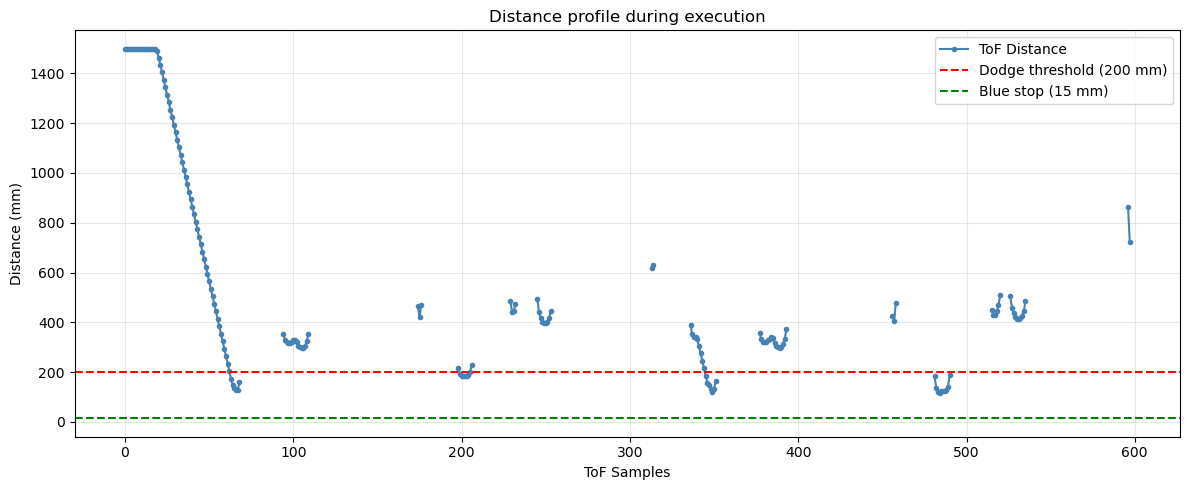

In [3]:
import time
import threading
import numpy as np
import cv2
import matplotlib.pyplot as plt
from robomaster import robot as rm_robot
from robomaster.robot import Robot

# ==========================================
# --- CONSTANTS AND PARAMETERS ---
# ==========================================
KP_YAW             = 1.5
MAX_Z              = 90.0  
OBSTACLE_DIST_MM   = 200
BLUE_STOP_MM       = 15
DODGE_Y_SPEED      = 0.45
FORWARD_SPEED      = 0.3
MAX_FWD_TIME       = 7.0
RETURN_FACTOR      = 1.10  
MIN_PIXELS         = 10000

# ==========================================
# --- GLOBAL THREAD-SAFE STATE ---
# ==========================================
_lock               = threading.Lock()
accumulated_yaw     = 0.0
target_yaw          = 0.0  
last_yaw            = None
current_distance    = 2000.0
readings            = []
last_turn_was_right = False 

# ==========================================
# --- SENSOR CALLBACKS ---
# ==========================================
def attitude_handler(attitude_info):
    global accumulated_yaw, last_yaw
    yaw = attitude_info[0]
    if last_yaw is None:
        last_yaw = yaw
        return
    delta = yaw - last_yaw
    if delta > 180:    delta -= 360
    elif delta < -180: delta += 360
    with _lock:
        accumulated_yaw += delta
    last_yaw = yaw

def distance_handler(data):
    global current_distance, readings
    dist = data[0]
    with _lock:
        current_distance = dist if dist != 65534 else 2000.0
        readings.append((abs(accumulated_yaw), current_distance))

# ==========================================
# --- YAW HELPER ---
# ==========================================
def get_z_correction(max_z: float = MAX_Z) -> float:
    with _lock:
        error = accumulated_yaw - target_yaw
    return float(np.clip(-KP_YAW * error, -max_z, max_z))

def reset_yaw_reference():
    global accumulated_yaw, last_yaw, target_yaw
    with _lock:
        accumulated_yaw = 0.0
        last_yaw = None
        target_yaw = 0.0

# ==========================================
# --- OPENCV VISION ---
# ==========================================
def detect_color(img_rgb: np.ndarray):
    hsv = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2HSV)
    mask_blue   = cv2.inRange(hsv, (99, 102, 51), (126, 255, 255))
    mask_black  = cv2.inRange(hsv, (0, 0, 0), (179, 255, 50))
    mask_orange = cv2.inRange(hsv, (3, 127, 51), (27, 255, 255))

    counts = {
        "blue":   cv2.countNonZero(mask_blue),
        "black":  cv2.countNonZero(mask_black),
        "orange": cv2.countNonZero(mask_orange),
    }
    dominant = max(counts, key=counts.get)
    return dominant if counts[dominant] > MIN_PIXELS else None

def guess_unknown_color(img_rgb: np.ndarray) -> str:
    h, w = img_rgb.shape[:2]
    roi = img_rgb[h // 4 : 3 * h // 4, w // 4 : 3 * w // 4]
    R, G, B = np.mean(roi, axis=(0, 1))
    if R > G and R > B:                  return "Red/Brown"
    if G > R and G > B:                  return "Green"
    if B > R and B > G:                  return "Blue/Purple"
    if R > 200 and G > 200 and B > 200:  return "White"
    return "Unknown"

# ==========================================
# --- STRAIGHT MOVEMENT HELPER ---
# ==========================================
def drive_corrected(robot, x: float, y: float, duration: float, label: str = ""):
    start = time.time()
    while time.time() - start < duration:
        robot.chassis.drive_speed(x=x, y=y, z=get_z_correction())
        frame = robot.camera.read_video_frame(strategy="newest")
        if frame is not None:
            disp = draw_overlay(frame, "", label)
            cv2.imshow("RoboMaster - Live", disp)
            cv2.waitKey(1)
        time.sleep(0.02)
    robot.chassis.drive_speed(x=0, y=0, z=0)

# ==========================================
# --- DODGE PROCEDURE ---
# ==========================================
def dodge_obstacle(robot, direction_y: float, obstacle_color: str):
    global target_yaw
    side = "RIGHT" if direction_y > 0 else "LEFT"
    print(f"\n[DODGE] Dodging to {side} | Obstacle: {obstacle_color}")

    # -- PHASE 1: Dynamic lateral dodge using ToF sensor --
    robot.chassis.drive_speed(x=0, y=0, z=0)
    time.sleep(0.1)
    
    print("[DODGE] Strafing laterally until forward path is clear...")
    start_dodge = time.time()
    clear_frames = 0
    actual_dodge_time = 0.0

    while time.time() - start_dodge < 4.0:
        robot.chassis.drive_speed(x=0.0, y=direction_y, z=get_z_correction())
        frame = robot.camera.read_video_frame(strategy="newest")

        with _lock:
            dist = current_distance

        # If ToF reads > 400mm, the obstacle is no longer directly in front of the center sensor
        if dist > 400:
            clear_frames += 1
        else:
            clear_frames = 0

        if frame is not None:
            elapsed = time.time() - start_dodge
            disp = frame.copy()
            cv2.putText(disp, f"Dynamic Dodge | {elapsed:.1f}s", (30, 50), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 255, 255), 2)
            cv2.imshow("RoboMaster - Live", disp)
            cv2.waitKey(1)

        # Wait for 3 consecutive clear readings to debounce sensor noise
        if clear_frames >= 3:
            break
                
        time.sleep(0.02)

    base_dodge_time = time.time() - start_dodge
    robot.chassis.drive_speed(x=0, y=0, z=0)
    
    # Increased clearance margin: the sensor is in the middle, so we need extra time 
    # to pull the rest of the chassis width past the obstacle edge.
    clearance_margin = 0.65 
    drive_corrected(robot, x=0.0, y=direction_y, duration=clearance_margin, label="CHASSIS CLEARANCE")
    
    actual_dodge_time = base_dodge_time + clearance_margin
    print(f"[DODGE] Path clear. Recorded lateral dodge time: {actual_dodge_time:.2f}s")

    # -- PHASE 2: Advance straight for 20 cm --
    print("[DODGE] Advancing straight for 20 cm...")
    drive_corrected(robot, x=FORWARD_SPEED, y=0.0, duration=0.7, label="ADVANCING 20cm")

    # -- PHASE 3: Rotate chassis 90 degrees --
    yaw_shift = -90.0 if direction_y > 0 else 90.0
    print("[DODGE] Rotating chassis to face the obstacle...")
    with _lock:
        target_yaw += yaw_shift
    
    drive_corrected(robot, x=0.0, y=0.0, duration=1.5, label="FACING OBSTACLE")

    # -- PHASE 4: Crab walk until obstacle is cleared --
    print("[DODGE] Crab walking along the obstacle...")
    obstacle_was_seen = False
    time_last_seen = time.time()
    start_fwd = time.time()

    crab_y = FORWARD_SPEED if direction_y > 0 else -FORWARD_SPEED

    while time.time() - start_fwd < MAX_FWD_TIME:
        robot.chassis.drive_speed(x=0.0, y=crab_y, z=get_z_correction())
        frame = robot.camera.read_video_frame(strategy="newest")

        if frame is not None:
            rgb = frame[:, :, ::-1]
            seen = detect_color(rgb)
            elapsed = time.time() - start_fwd

            disp = frame.copy()
            cv2.putText(disp, f"Crab Walk | {elapsed:.1f}s", (30, 50), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 255, 255), 2)
            cv2.putText(disp, f"Seeing: {seen}", (30, 85), cv2.FONT_HERSHEY_SIMPLEX, 0.65, (255, 255, 0), 2)
            cv2.imshow("RoboMaster - Live", disp)
            cv2.waitKey(1)

            if obstacle_color == "Unknown":
                if elapsed > 1.5: 
                    break
            else:
                if seen == obstacle_color:
                    obstacle_was_seen = True
                    time_last_seen = time.time()
                elif obstacle_was_seen:
                    time_blind = time.time() - time_last_seen
                    if time_blind > 0.17: 
                        print("[DODGE] 5 cm blind walk complete. Obstacle cleared.")
                        break
                elif elapsed > 0.8:
                    print("[DODGE] Obstacle not found in lateral view. Assuming cleared.")
                    break

        time.sleep(0.02)

    robot.chassis.drive_speed(x=0, y=0, z=0)

    # -- PHASE 5: Realign chassis forward --
    print("[DODGE] Realigning chassis forward...")
    with _lock:
        target_yaw -= yaw_shift
    drive_corrected(robot, x=0.0, y=0.0, duration=1.5, label="REALIGNING FORWARD")

    # -- PHASE 6: Dynamic return to path --
    return_duration = actual_dodge_time * RETURN_FACTOR
    print(f"[DODGE] Returning to exact path layout for {return_duration:.2f}s...")
    drive_corrected(robot, x=0.0, y=-direction_y, duration=return_duration, label="RETURNING TO PATH")
    
    time.sleep(0.2) 
    print("[DODGE] Dodge maneuver complete. Resuming path.\n")

# ==========================================
# --- VIDEO OVERLAY ---
# ==========================================
def draw_overlay(frame, color_seen, state_msg):
    display = frame.copy()
    with _lock:
        dist = current_distance
        yaw  = accumulated_yaw
        t_yaw = target_yaw
    lines = [
        (f"State: {state_msg}",      (0, 255, 0)),
        (f"Color: {color_seen}",     (255, 255, 0)),
        (f"Dist: {dist:.0f} mm",     (0, 255, 255)),
        (f"Yaw: {yaw:+.1f} deg (Target: {t_yaw:+.0f})", (255, 100, 100)),
    ]
    for i, (text, color) in enumerate(lines):
        cv2.putText(display, text, (10, 30 + i * 30), cv2.FONT_HERSHEY_SIMPLEX, 0.65, color, 2)
        
    bar_len   = int(np.clip(dist / OBSTACLE_DIST_MM * 200, 0, 200))
    bar_color = (0, 255, 0) if dist > OBSTACLE_DIST_MM else (0, 0, 255)
    cv2.rectangle(display, (10, 155), (10 + bar_len, 175), bar_color, -1)
    cv2.rectangle(display, (10, 155), (210, 175), (200, 200, 200), 1)
    return display

# ==========================================
# --- MAIN EXECUTION ---
# ==========================================
robot = Robot()
robot.initialize(conn_type="sta", sn="LOCAL")

try:
    print("Initializing sensors and camera...")
    
    robot.set_robot_mode(mode=rm_robot.FREE)
    
    robot.chassis.sub_attitude(freq=50, callback=attitude_handler)
    robot.sensor.sub_distance(freq=10, callback=distance_handler)
    robot.camera.start_video_stream(display=False, resolution="720p")
    
    try:
        robot.gimbal.recenter().wait_for_completed(timeout=2)
    except:
        pass
        
    time.sleep(1.5)
    reset_yaw_reference()
    print("\nRobot ready. Press 'Q' on the video window to stop.\n")

    while True:
        frame = robot.camera.read_video_frame(strategy="newest")
        if frame is None:
            time.sleep(0.01)
            continue

        rgb_frame  = frame[:, :, ::-1]
        color_seen = detect_color(rgb_frame)

        with _lock:
            dist = current_distance

        # --- 1. BLUE TARGET ---
        if color_seen == "blue":
            if dist > BLUE_STOP_MM:
                state_msg = "Seeing BLUE: Approaching..."
                speed_x   = 0.20 if dist > 100 else 0.05
                robot.chassis.drive_speed(x=speed_x, y=0.0, z=get_z_correction(max_z=15.0))
            else:
                state_msg = "BLUE TARGET REACHED"
                robot.chassis.drive_speed(x=0, y=0, z=0)

        # --- 2. DODGE ---
        elif dist <= OBSTACLE_DIST_MM:
            robot.chassis.drive_speed(x=0, y=0, z=0)
            
            direction_y = +DODGE_Y_SPEED if not last_turn_was_right else -DODGE_Y_SPEED

            if color_seen == "black":
                state_msg = f"BLACK -> {'RIGHT' if direction_y > 0 else 'LEFT'}"
                dodge_obstacle(robot, direction_y=direction_y, obstacle_color="black")
            elif color_seen == "orange":
                state_msg = f"ORANGE -> {'RIGHT' if direction_y > 0 else 'LEFT'}"
                dodge_obstacle(robot, direction_y=direction_y, obstacle_color="orange")
            else:
                guessed   = guess_unknown_color(rgb_frame)
                state_msg = f"Obstacle ({guessed}) -> {'RIGHT' if direction_y > 0 else 'LEFT'}"
                dodge_obstacle(robot, direction_y=direction_y, obstacle_color="Unknown")

            last_turn_was_right = (direction_y > 0)

        # --- 3. FREE ADVANCE ---
        else:
            state_msg = f"Advancing | Seeing: {color_seen}" if color_seen else "Advancing"
            robot.chassis.drive_speed(x=FORWARD_SPEED, y=0.0, z=get_z_correction())

        cv2.imshow("RoboMaster - Live", draw_overlay(frame, str(color_seen), state_msg))
        if cv2.waitKey(1) & 0xFF == ord('q'):
            print("\nShutdown requested.")
            break
            
        time.sleep(0.02)

except KeyboardInterrupt:
    print("\nManual interrupt.")
finally:
    print("\nShutting down...")
    robot.chassis.drive_speed(x=0, y=0, z=0)
    robot.sensor.unsub_distance()
    robot.chassis.unsub_attitude()
    cv2.destroyAllWindows()
    try:
        robot.camera.stop_video_stream()
        time.sleep(0.5)
        robot.close()
    except:
        pass

# ==========================================
# --- FINAL PLOT ---
# ==========================================
print("\nGenerating plot...")
if readings:
    dists_c = [d if d < 1999 else np.nan for _, d in readings]
    plt.figure(figsize=(12, 5))
    plt.plot(range(len(dists_c)), dists_c, '-o', markersize=3, color="steelblue", label="ToF Distance")
    plt.axhline(y=OBSTACLE_DIST_MM, color='red',   linestyle='--', label=f"Dodge threshold ({OBSTACLE_DIST_MM} mm)")
    plt.axhline(y=BLUE_STOP_MM,     color='green', linestyle='--', label=f"Blue stop ({BLUE_STOP_MM} mm)")
    plt.title("Distance profile during execution")
    plt.xlabel("ToF Samples")
    plt.ylabel("Distance (mm)")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()
else:
    print("No data acquired.")